<a href="https://colab.research.google.com/github/shivaleelahvanaki-ops/Shivaleela/blob/main/gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install -q tensorflow opencv-python matplotlib

In [19]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [20]:
uploaded = files.upload()

Saving archive (2).zip to archive (2) (1).zip


In [21]:
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [22]:
print(os.listdir())

['.config', 'dataset', 'emotion_model.keras', 'archive (2) (1).zip', 'archive (2).zip', 'train', 'test', 'sample_data']


In [23]:
import os

print("Train Classes:")
print(os.listdir("train"))

print("\nTest Classes:")
print(os.listdir("test"))

Train Classes:
['neutral', 'fear', 'happy', 'angry', 'disgust', 'surprise', 'sad']

Test Classes:
['neutral', 'fear', 'happy', 'angry', 'disgust', 'surprise', 'sad']


In [24]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    "train",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "test",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


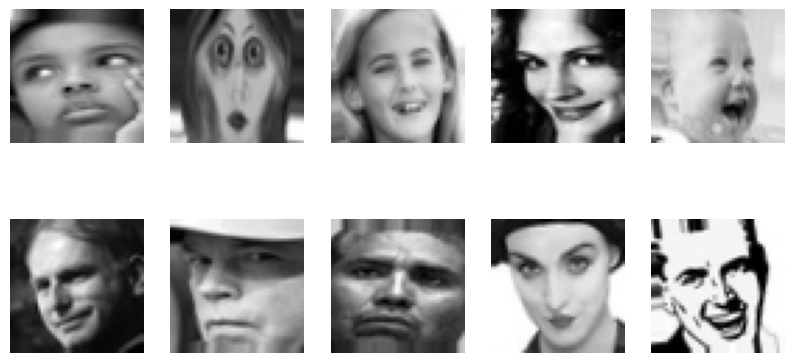

In [25]:
images, labels = next(train_generator)

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].reshape(48,48), cmap='gray')
    plt.axis("off")

plt.show()

In [26]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,015 (2.36 MB)

 Trainable params: 619,015 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.2781 - loss: 1.7634 - val_accuracy: 0.3700 - val_loss: 1.6066
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.3797 - loss: 1.5902 - val_accuracy: 0.4486 - val_loss: 1.4454
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.4289 - loss: 1.4785 - val_accuracy: 0.4713 - val_loss: 1.3787
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.4596 - loss: 1.4056 - val_accuracy: 0.5003 - val_loss: 1.3014
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.4813 - loss: 1.3609 - val_accuracy: 0.5088 - val_loss: 1.2787
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.4963 - loss: 1.3300 - val_accuracy: 0.5339 - val_loss: 1.2204
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.5098 - loss: 1.2985 - val_accuracy: 0.5386 - val_loss: 1.2116
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.5179 - loss: 1.2753 - 

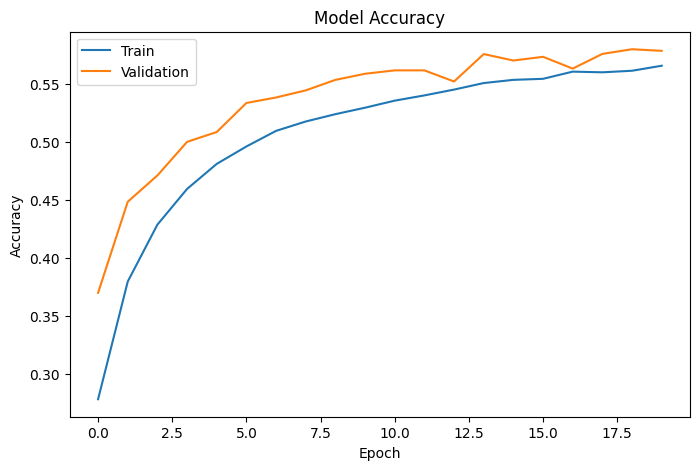

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

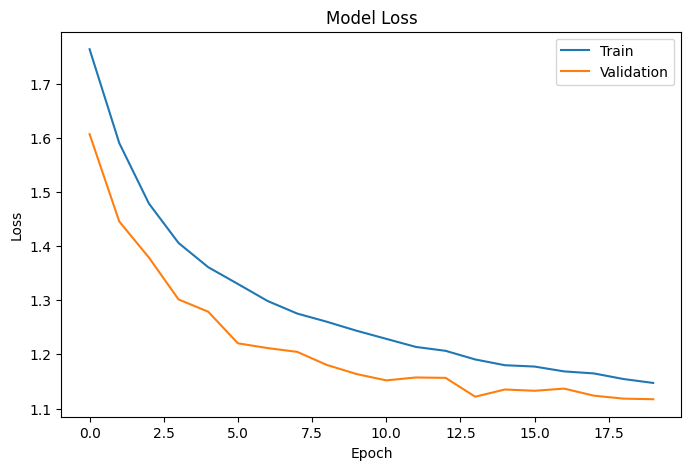

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [32]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy :", accuracy)
print("Test Loss :", loss)

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5789 - loss: 1.1171
Test Accuracy : 0.5788520574569702
Test Loss : 1.1171469688415527


In [33]:
model.save("emotion_detection_model.keras")

In [34]:
from tensorflow.keras.preprocessing import image

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

uploaded = files.upload()

img_name = list(uploaded.keys())[0]

img = image.load_img(
    img_name,
    color_mode='grayscale',
    target_size=(48,48)
)

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Predicted Emotion :", emotion_labels[np.argmax(prediction)])

Saving PublicTest_9617686.jpg to PublicTest_9617686.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
Predicted Emotion : Neutral


In [35]:
from tensorflow.keras.preprocessing import image

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

uploaded = files.upload()

img_name = list(uploaded.keys())[0]

img = image.load_img(
    img_name,
    color_mode='grayscale',
    target_size=(48,48)
)

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Predicted Emotion :", emotion_labels[np.argmax(prediction)])

Saving PublicTest_93755857.jpg to PublicTest_93755857.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Emotion : Neutral


In [36]:
from tensorflow.keras.preprocessing import image

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

uploaded = files.upload()

img_name = list(uploaded.keys())[0]

img = image.load_img(
    img_name,
    color_mode='grayscale',
    target_size=(48,48)
)

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Predicted Emotion :", emotion_labels[np.argmax(prediction)])

Saving PublicTest_81742978.jpg to PublicTest_81742978.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Emotion : Neutral
